In [2]:
import scipy.sparse as sp
import numpy as np

real_graph = sp.load_npz('../testing graphs/mobility_graph_csr.npz')
# synthetic_graph = sp.load_npz('testing graphs/synthetic_graph.npz')
# synthetic_graph2 = sp.load_npz('testing graphs/synthetic_graph_2.npz')
#
# synthetic_graphfixedmaybe = sp.load_npz('synthetic_graph_fixed?.npz')
# synthetic_graphfixedpls = sp.load_npz('testing graphs/synthetic_graph_fixedpls.npz')
#
# synthetic_graphfixedidk = sp.load_npz('testing graphs/synthetic_graph_g0.55,d0.0028.npz')
#
# synthetic_graphhopesandprayers = sp.load_npz('testing graphs/please.npz')
#
#
# synthetic_graphhopesandprayers = sp.load_npz('testing graphs/whatever.npz')
#
#
# radiation_graph = sp.load_npz('testing graphs/synthetic_FUllradiation.npz')
# radiation_graph2 = sp.load_npz('testing graphs/synthetic_radiationK.npz')
#
test = sp.load_npz('../testing graphs/testing.npz')

testing = sp.load_npz('../testing graphs/radiation_newtest.npz')


data = np.load('../testing graphs/mobility_metadata_real.npz')
population_real = data['population']

data = np.load('../testing graphs/mobility_metadata_newtest2.npz')
population_test = data['population']

population_test.size

3219

In [11]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel

def compute_mmd(x, y, gamma=1.0):



    x = x.reshape(-1, 1)

    y = y.reshape(-1, 1)



    k_xx = rbf_kernel(x, x, gamma=gamma).mean()
    k_yy = rbf_kernel(y, y, gamma=gamma).mean()

    k_xy = rbf_kernel(x, y, gamma=gamma).mean()


    return k_xx + k_yy - 2 * k_xy


gen_degrees = np.array(testing.sum(axis=0)).flatten()
real_degrees = np.array(real_graph.sum(axis=0)).flatten()

gen_log = np.log1p(gen_degrees)
real_log = np.log1p(real_degrees)




from scipy.spatial.distance import pdist

# Combine a sample of both to find a good scale
combined = np.concatenate([gen_log[:1000], real_log[:1000]]).reshape(-1, 1)
median_dist = np.median(pdist(combined))
# A common heuristic: gamma = 1 / (2 * median_dist**2)

new_gamma = 1.0 / (2 * median_dist**2)
print(new_gamma)

mmd_score = compute_mmd(gen_log, real_log, gamma=new_gamma)

print(f"MMD Score: {mmd_score}")






4.5072021341448154e+30
MMD Score: -0.016910312632907987


In [11]:
gen_log = np.log1p(population_test)
real_log = np.log1p(population_real)


from scipy.spatial.distance import pdist

# Combine a sample of both to find a good scale
combined = np.concatenate([gen_log[:1000], real_log[:1000]]).reshape(-1, 1)
median_dist = np.median(pdist(combined))
# A common heuristic: gamma = 1 / (2 * median_dist**2)
new_gamma = 1.0 / (2 * median_dist**2)

mmd_score = compute_mmd(gen_log, real_log, gamma=new_gamma)
mmd_score

0.24680595843175424

In [1]:
import matplotlib.pyplot as plt
import numpy as np
def plot_normalized_comparison(gen_deg, real_deg):
    plt.figure(figsize=(10, 6))

    for data, label, color in zip([gen_deg, real_deg], ['Synthetic', 'Real'], ['red', 'blue']):
        # Sort and plot rank-size (no binning needed!)
        sorted_degrees = np.sort(data)[::-1]
        ranks = np.arange(1, len(sorted_degrees) + 1)

        plt.loglog(ranks, sorted_degrees, 'o', label=label, color=color, alpha=0.6, markersize=3)

    plt.title("Degree Rank-Size Distribution (Normalized Flow)")
    plt.xlabel("Rank")
    plt.ylabel("Normalized Degree (Total Flow / Total Sum)")
    plt.legend()
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

plot_normalized_comparison(gen_degrees, real_degrees)

NameError: name 'gen_degrees' is not defined

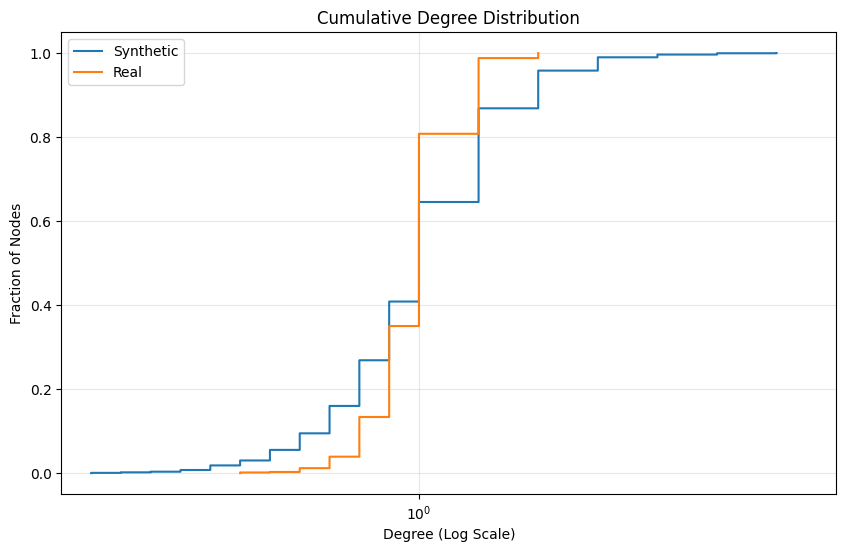

In [88]:
def plot_cdf(gen_deg, real_deg):
    plt.figure(figsize=(10, 6))

    for data, label in zip([gen_deg, real_deg], ['Synthetic', 'Real']):
        # Sort data to create CDF
        x = np.sort(data)
        y = np.arange(1, len(data) + 1) / len(data)
        plt.step(x, y, label=label)

    plt.xscale('log')
    plt.title("Cumulative Degree Distribution")
    plt.xlabel("Degree (Log Scale)")
    plt.ylabel("Fraction of Nodes")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_cdf(gen_degrees, real_degrees)

In [14]:
def edge_density(graph):

    non_zero_edges = graph.nnz

    v = graph.shape[0] #number  nodes

    return non_zero_edges / (v * (v - 1)) * 100




In [16]:
edge_density(real_graph)

4.749312223434081

In [17]:
edge_density(testing)

4.988260157459274

In [9]:
def check_weight_heterogeneity(sparse_matrix):

    weights = sparse_matrix.data

    std = np.std(weights)
    mean = np.mean(weights)

    cv = std / mean


    print(f"Mean Weight: {mean:.6f}")
    print(f"Std Dev: {std:.6f}")
    print(f"Coefficient of Variation (CV): {cv:.4f}")

    return cv

# Usage
print('synthethic')
check_weight_heterogeneity(testing)
print('real')
check_weight_heterogeneity(real_graph)


synthethic
Mean Weight: 0.006842
Std Dev: 0.042174
Coefficient of Variation (CV): 6.1642
real
Mean Weight: 0.006543
Std Dev: 0.047937
Coefficient of Variation (CV): 7.3264


7.326401690426553

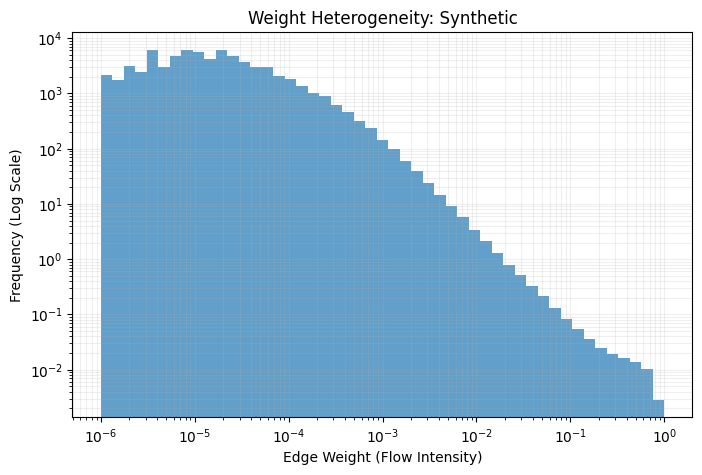

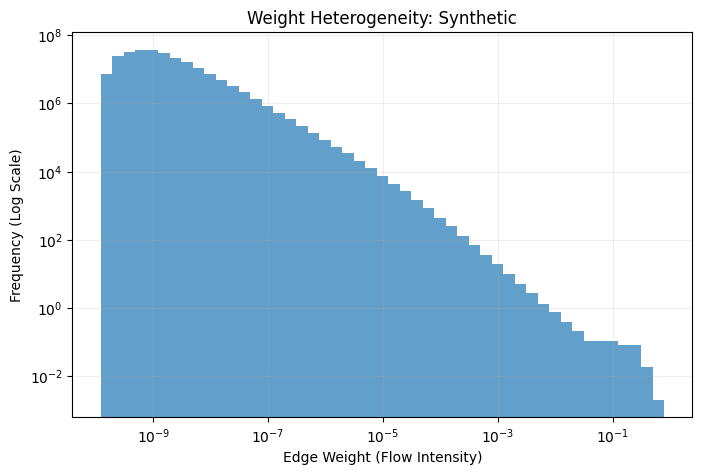

In [64]:
import matplotlib.pyplot as plt

def plot_weight_distribution(sparse_matrix, label="Synthetic"):
    weights = sparse_matrix.data

    plt.figure(figsize=(8, 5))
    # Using log-spaced bins is essential for heterogeneous data
    bins = np.logspace(np.log10(weights.min()), np.log10(weights.max()), 50)
    plt.hist(weights, bins=bins, density=True, alpha=0.7, label=label)

    plt.xscale('log')
    plt.yscale('log')
    plt.xlabel('Edge Weight (Flow Intensity)')
    plt.ylabel('Frequency (Log Scale)')
    plt.title(f'Weight Heterogeneity: {label}')
    plt.grid(True, which="both", ls="-", alpha=0.2)
    plt.show()

plot_weight_distribution(real_graph)
plot_weight_distribution(testing)

In [3]:
import numpy as np
from scipy.sparse import csr_matrix

def node_weight_heterogeneity(sparse_matrix):
    """
    Calculates the Mean, Std, and CV of edge weights for each node.
    Returns three 1D numpy arrays of length N.
    """
    # 1. Ensure CSR format (crucial for row-wise operations)
    mat = sparse_matrix.tocsr()

    # 2. Get the degree (number of edges) for each node
    degrees = mat.getnnz(axis=1).astype(float)

    # Prevent division by zero for isolated nodes (degree = 0)
    safe_degrees = degrees.copy()
    safe_degrees[safe_degrees == 0] = 1.0

    # 3. Calculate Mean per node
    # .sum(axis=1) returns a 2D column matrix, .A1 flattens it to a 1D array
    node_sums = mat.sum(axis=1).A1
    node_means = node_sums / safe_degrees

    # 4. Calculate Standard Deviation per node
    # Using the formula: Var(X) = Mean(X^2) - Mean(X)^2
    sq_mat = mat.copy()
    sq_mat.data = sq_mat.data ** 2

    node_sq_sums = sq_mat.sum(axis=1).A1
    node_variances = (node_sq_sums / safe_degrees) - (node_means ** 2)

    # Clean up tiny negative numbers caused by floating point inaccuracies
    node_variances = np.maximum(node_variances, 0)
    node_stds = np.sqrt(node_variances)

    # 5. Calculate Coefficient of Variation (CV) per node
    safe_means = node_means.copy()
    safe_means[safe_means == 0] = 1e-8 # Prevent division by zero if mean is 0

    node_cvs = node_stds / safe_means

    # 6. Handle edge cases
    # Set CV to 0 for nodes with 0 edges or 1 edge (no variation)
    node_cvs[degrees <= 1] = 0.0

    return node_means, node_stds, node_cvs

# --- Usage ---
print('Synthetic per-node stats:')
gen_means, gen_stds, gen_cvs = node_weight_heterogeneity(testing)

print('Real per-node stats:')
real_means, real_stds, real_cvs = node_weight_heterogeneity(real_graph)

# Now you can look at global summaries of these node-level stats
print(f"Average Real Node CV: {np.mean(real_cvs):.4f}")
print(f"Average Gen Node CV: {np.mean(gen_cvs):.4f}")

Synthetic per-node stats:
Real per-node stats:
Average Real Node CV: 6.7592
Average Gen Node CV: 6.2216


In [1]:
import numpy as np
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import pdist


def compute_mmd(x, y, gamma=1.0):


    k_xx = rbf_kernel(x, x, gamma=gamma).mean()
    k_yy = rbf_kernel(y, y, gamma=gamma).mean()

    k_xy = rbf_kernel(x, y, gamma=gamma).mean()

    return k_xx + k_yy - 2 * k_xy


scaler = StandardScaler()

gen_degrees = np.array(testing.sum(axis=0)).flatten()
real_degrees = np.array(real_graph.sum(axis=0)).flatten()

gen_log_degree = np.log1p(gen_degrees)
real_log_degree = np.log1p(real_degrees)

gen_log_population = np.log1p(population_test)

real_log_population= np.log1p(population_real)



real_features = np.column_stack([
    real_log_population,
    real_log_degree,
    real_cvs
])

gen_features = np.column_stack([
    gen_log_population,
    gen_log_degree,
    gen_cvs,
])


real_features_scaled = scaler.fit_transform(real_features)
gen_features_scaled = scaler.transform(gen_features)

sample_size = min(1000, len(gen_features_scaled), len(real_features_scaled))
combined = np.vstack([
    gen_features_scaled[:sample_size],
    real_features_scaled[:sample_size]
])


median_dist = np.median(pdist(combined, metric='euclidean'))

# Prevent division by zero if all sampled points are identical
if median_dist == 0:
    new_gamma = 1.0
else:
    new_gamma = 1.0 / (2 * median_dist**2)

print(new_gamma)
#
mmd_score = compute_mmd(gen_features_scaled, real_features_scaled, gamma=new_gamma)

print(f"Multivariate MMD Score: {mmd_score}")

NameError: name 'testing' is not defined